In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [5]:
df=pd.read_csv(r"C:\Users\Aditya Kumar\OneDrive\Desktop\Ml_project_2\heart.csv") # Load the dataset
df.head() # Display the first few rows of the dataset


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
# EDA (Exploratory Data Analysis)
df.columns # Display the column names

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [7]:
df.shape # Display the shape of the dataset (number of rows and columns)

(918, 12)

In [8]:
df.info() # Display information about the dataset, including data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [9]:
df.describe() # Display summary statistics for numerical columns in the dataset

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [10]:
df.duplicated().sum() # Check for duplicate rows in the dataset

0

<Axes: xlabel='HeartDisease'>

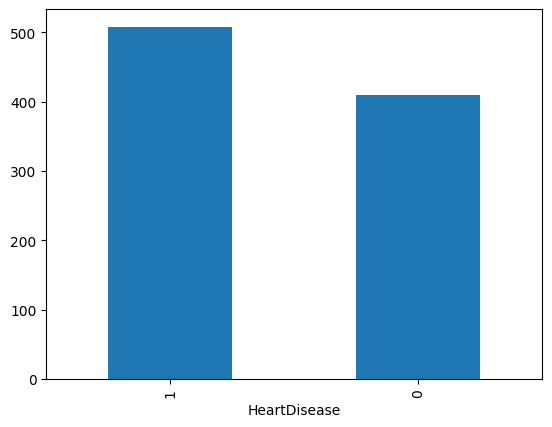

In [12]:
df['HeartDisease'].value_counts().plot(kind='bar')       # Count the occurrences of each class in the target variable

In [13]:
df.isnull().sum() # Check for missing values in the dataset

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

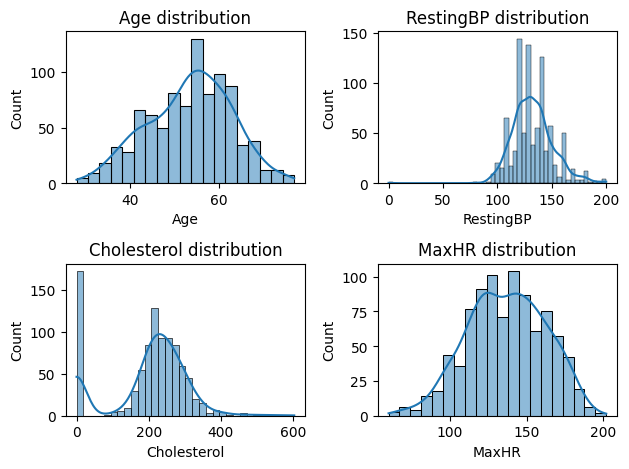

In [36]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    plt.title(f'{var} distribution')
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()
# from the above distribution we can see that there are some outliers in the dataset which we will handle in the next step
# We can also see that the distribution of the target variable is imbalanced which we will handle in the next step as well
# We can also see that there are some missing values in the dataset which we will handle in the next step as well
# in restingBP column there are some values which are 0 which is not possible so we will handle that in the next step as well
# cholesterol column also has 172 values which are 0 which is not possible so we will handle that in the next step as well

In [37]:
# first i will fill 0 values of cholestrol with meaan value of cholestrol column
ch_mean=df.loc[df['Cholesterol']!=0, 'Cholesterol'].mean() # Calculate the mean of the Cholesterol column excluding 0 values



In [38]:
ch_mean # Display the calculated mean value for Cholesterol

244.6353887399464

In [39]:
df['Cholesterol'].value_counts() # Check the value counts of the Cholesterol column 

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

In [43]:
df['Cholesterol']=df['Cholesterol'].replace(0,ch_mean) # Replace 0 values in the Cholesterol column with the calculated mean value
df['Cholesterol']=df['Cholesterol'].round(2)


In [41]:
df['Cholesterol']=df['Cholesterol'].round(2)

# Round the values in the Cholesterol column to 2 decimal places



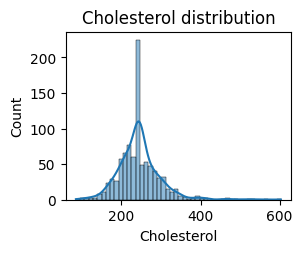

In [44]:
ch_mean # Display the calculated mean value for Cholesterol
plotting('Cholesterol',3) # Plot the distribution of the Cholesterol column after replacing 0 values with the mean value

In [45]:
# for restingbp column we will fill 0 values with mean value of restingbp column
rb_mean=df.loc[df['RestingBP']!=0, 'RestingBP'].mean() # Calculate the mean of the RestingBP column excluding 0 values
rb_mean # Display the calculated mean value for RestingBP
df['restingbp']=df['RestingBP'].replace(0,rb_mean) # Replace 0 values in the RestingBP column with the calculated mean value
df['restingbp']=df['RestingBP'].round(2) # Round the values in the RestingBP column to 2 decimal places
rb_mean # Display the calculated mean value for RestingBP after rounding

132.54089422028352

In [46]:
df['restingbp']=df['RestingBP'].round(2)

In [47]:
rb_mean # Display the calculated mean value for RestingBP after rounding

132.54089422028352

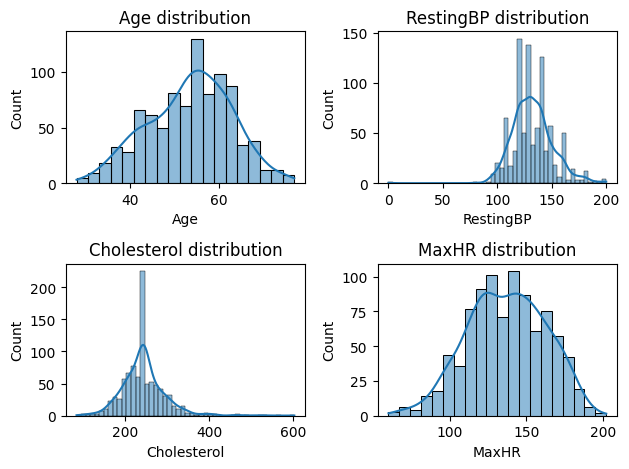

In [48]:
def plotting(var,num):
    plt.subplot(2,2,num)
    sns.histplot(df[var],kde=True)
    plt.title(f'{var} distribution')
plotting('Age',1)
plotting('RestingBP',2)
plotting('Cholesterol',3)
plotting('MaxHR',4)
plt.tight_layout()

In [49]:
pip install sheryanalysis==0.1.0

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [52]:
import sheryanalysis as sh
sh.analyze(df)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (918, 14)
🧱 Columns: ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'cholesterol', 'restingbp']

✅ No null values found

🔠 Categorical Columns: ['Sex', 'ChestPainType', 'FastingBS', 'RestingECG', 'ExerciseAngina', 'ST_Slope', 'HeartDisease']

🔢 Numerical Columns: ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'cholesterol', 'restingbp']


{'shape': (918, 14),
 'columns': ['Age',
  'Sex',
  'ChestPainType',
  'RestingBP',
  'Cholesterol',
  'FastingBS',
  'RestingECG',
  'MaxHR',
  'ExerciseAngina',
  'Oldpeak',
  'ST_Slope',
  'HeartDisease',
  'cholesterol',
  'restingbp'],
 'dtypes': {'Age': dtype('int64'),
  'Sex': dtype('O'),
  'ChestPainType': dtype('O'),
  'RestingBP': dtype('int64'),
  'Cholesterol': dtype('float64'),
  'FastingBS': dtype('int64'),
  'RestingECG': dtype('O'),
  'MaxHR': dtype('int64'),
  'ExerciseAngina': dtype('O'),
  'Oldpeak': dtype('float64'),
  'ST_Slope': dtype('O'),
  'HeartDisease': dtype('int64'),
  'cholesterol': dtype('int64'),
  'restingbp': dtype('int64')},
 'null_counts': {'Age': 0,
  'Sex': 0,
  'ChestPainType': 0,
  'RestingBP': 0,
  'Cholesterol': 0,
  'FastingBS': 0,
  'RestingECG': 0,
  'MaxHR': 0,
  'ExerciseAngina': 0,
  'Oldpeak': 0,
  'ST_Slope': 0,
  'HeartDisease': 0,
  'cholesterol': 0,
  'restingbp': 0},
 'total_rows': 918,
 'column_types': {'categorical': ['Sex',
   'C

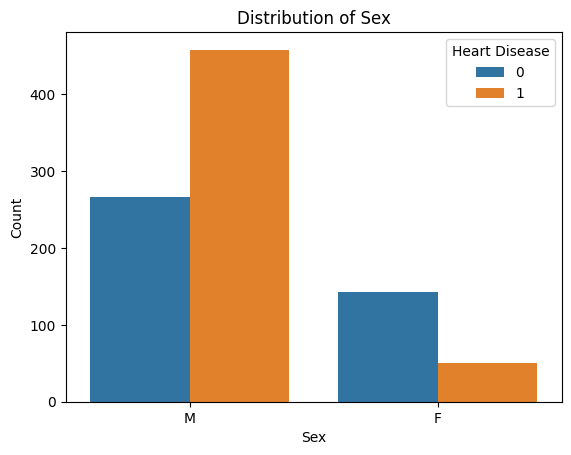

In [59]:
sns.countplot(x=df['Sex'],data=df,hue=df['HeartDisease'])
 # Count the occurrences of each class in the target variable
plt.title('Distribution of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Heart Disease')


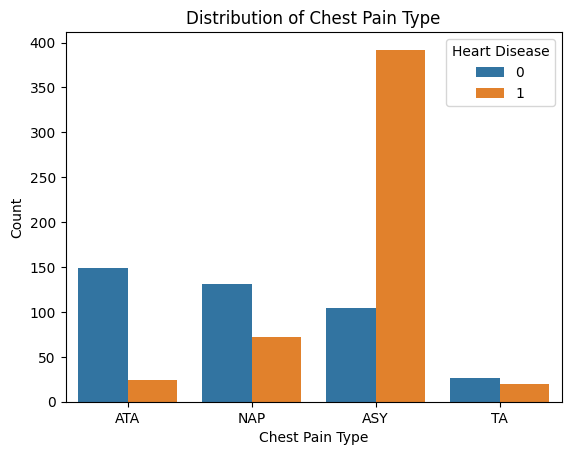

In [58]:
sns.countplot(x=df['ChestPainType'],data=df,hue=df['HeartDisease'])
plt.title('Distribution of Chest Pain Type')
plt.xlabel('Chest Pain Type')
plt.ylabel('Count')
plt.legend(title='Heart Disease')


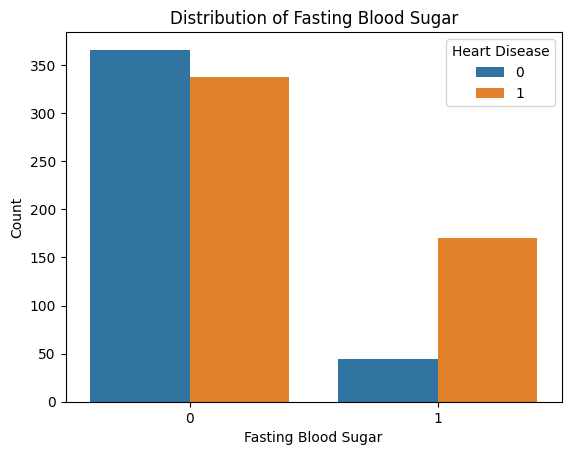

In [60]:
sns.countplot(x=df['FastingBS'],data=df,hue=df['HeartDisease'])
plt.title('Distribution of Fasting Blood Sugar')
plt.xlabel('Fasting Blood Sugar')
plt.ylabel('Count')
plt.legend(title='Heart Disease')

In [ ]:
# boxplot can be used to visualize the distribution of a numerical variable and identify outliers. 
# It displays the median, quartiles, and potential outliers in the data.
# it can relate categorical variables with numerical variables. 
# For example, we can use a boxplot to visualize the distribution of cholesterol levels for different chest pain types. 
# This can help us identify if there are any significant differences in cholesterol levels between the different chest pain types, which may be relevant for predicting heart disease.

Text(0.5, 1.0, 'Distribution of Cholesterol by Heart Disease')

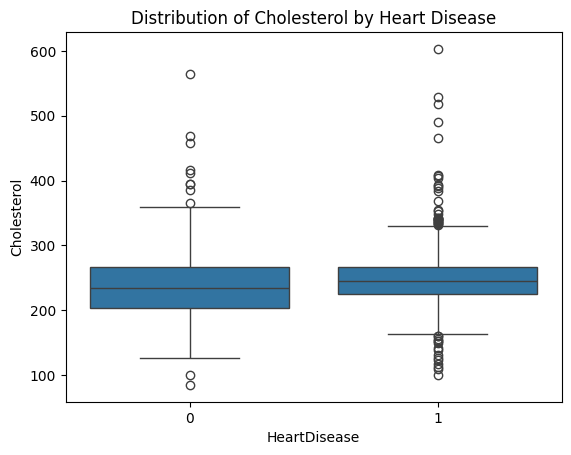

In [62]:
sns.boxplot(x='HeartDisease',y='Cholesterol',data=df)
plt.title('Distribution of Cholesterol by Heart Disease')


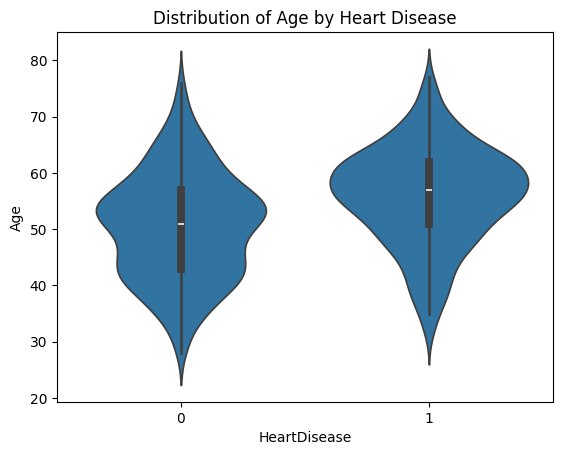

In [64]:
sns.violinplot(x='HeartDisease',y='Age',data=df)
plt.title('Distribution of Age by Heart Disease')
plt.show()

<Axes: >

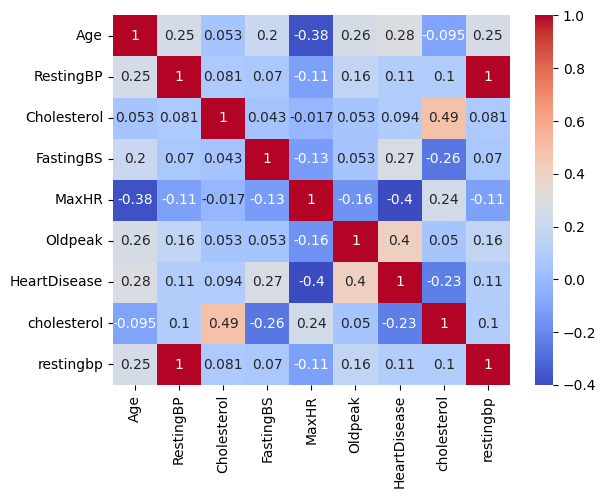

In [ ]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
# 

Data Preprocessing and Cleaning

In [83]:
# Data Preprocessing and Cleaning
df_encode=pd.get_dummies(df,drop_first=True) 
df_encode # Perform one-hot encoding on categorical variables in the dataset, dropping the first category to avoid multicollinearity 

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,cholesterol,restingbp,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289.0,0,172,0.0,0,289,140,True,True,False,False,True,False,False,False,True
1,49,160,180.0,0,156,1.0,1,180,160,False,False,True,False,True,False,False,True,False
2,37,130,283.0,0,98,0.0,0,283,130,True,True,False,False,False,True,False,False,True
3,48,138,214.0,0,108,1.5,1,214,138,False,False,False,False,True,False,True,True,False
4,54,150,195.0,0,122,0.0,0,195,150,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264.0,0,132,1.2,1,264,110,True,False,False,True,True,False,False,True,False
914,68,144,193.0,1,141,3.4,1,193,144,True,False,False,False,True,False,False,True,False
915,57,130,131.0,0,115,1.2,1,131,130,True,False,False,False,True,False,True,True,False
916,57,130,236.0,0,174,0.0,1,236,130,False,True,False,False,False,False,False,True,False


In [86]:
df_encode.astype('int')

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,cholesterol,restingbp,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0,289,140,1,1,0,0,1,0,0,0,1
1,49,160,180,0,156,1,1,180,160,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0,0,283,130,1,1,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1,214,138,0,0,0,0,1,0,1,1,0
4,54,150,195,0,122,0,0,195,150,1,0,1,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1,1,264,110,1,0,0,1,1,0,0,1,0
914,68,144,193,1,141,3,1,193,144,1,0,0,0,1,0,0,1,0
915,57,130,131,0,115,1,1,131,130,1,0,0,0,1,0,1,1,0
916,57,130,236,0,174,0,1,236,130,0,1,0,0,0,0,0,1,0


In [96]:
df_encode.head() # Display the first few rows of the encoded dataset

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,cholesterol,restingbp,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.398662,-0.031751,-0.069751,0,1.535481,-0.383983,0,289,140,1,1,0,0,1,0,0,0,1
1,0.045626,1.356222,-1.432128,0,0.016546,-0.383983,1,180,160,0,0,1,0,1,0,0,1,0
2,-1.398662,-0.031751,-0.069751,0,-1.502389,-0.383983,0,283,130,1,1,0,0,0,1,0,0,1
3,0.045626,-0.031751,-0.069751,0,-1.502389,-0.383983,1,214,138,0,0,0,0,1,0,1,1,0
4,0.045626,-0.031751,-0.069751,0,0.016546,-0.383983,0,195,150,1,0,1,0,1,0,0,0,1


In [92]:
df_encode = df_encode.astype('int')# Convert the data type of the DataFrame to int for compatibility with machine learning algorithms

In [93]:
df_encode.head() # Display the first few rows of the encoded dataset

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,cholesterol,restingbp,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1,0,0,0,1,0,0,289,140,1,1,0,0,1,0,0,0,1
1,0,1,-1,0,0,0,1,180,160,0,0,1,0,1,0,0,1,0
2,-1,0,0,0,-1,0,0,283,130,1,1,0,0,0,1,0,0,1
3,0,0,0,0,-1,0,1,214,138,0,0,0,0,1,0,1,1,0
4,0,0,0,0,0,0,0,195,150,1,0,1,0,1,0,0,0,1


In [94]:
# use regression model to predict the target variable 'HeartDisease' using the other features in the dataset. We will split the dataset into training and testing sets, fit the model on the training set, and evaluate its performance on the testing set.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numeric_features = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
df_encode[numeric_features] = scaler.fit_transform(df_encode[numeric_features])

In [95]:
df_encode.head() # Display the first few rows of the encoded dataset

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,cholesterol,restingbp,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,-1.398662,-0.031751,-0.069751,0,1.535481,-0.383983,0,289,140,1,1,0,0,1,0,0,0,1
1,0.045626,1.356222,-1.432128,0,0.016546,-0.383983,1,180,160,0,0,1,0,1,0,0,1,0
2,-1.398662,-0.031751,-0.069751,0,-1.502389,-0.383983,0,283,130,1,1,0,0,0,1,0,0,1
3,0.045626,-0.031751,-0.069751,0,-1.502389,-0.383983,1,214,138,0,0,0,0,1,0,1,1,0
4,0.045626,-0.031751,-0.069751,0,0.016546,-0.383983,0,195,150,1,0,1,0,1,0,0,0,1
